In [1]:
import matplotlib.pyplot as plt
import numpy as np

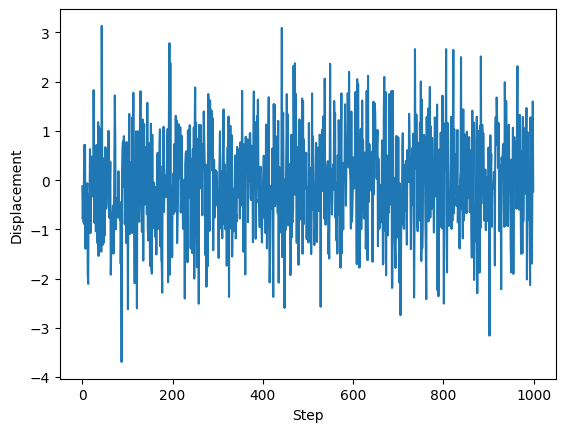

In [10]:
N = 1000
displacements = np.random.randn(N)
plt.plot(displacements)
plt.ylabel('Displacement')
plt.xlabel('Step')
plt.show()

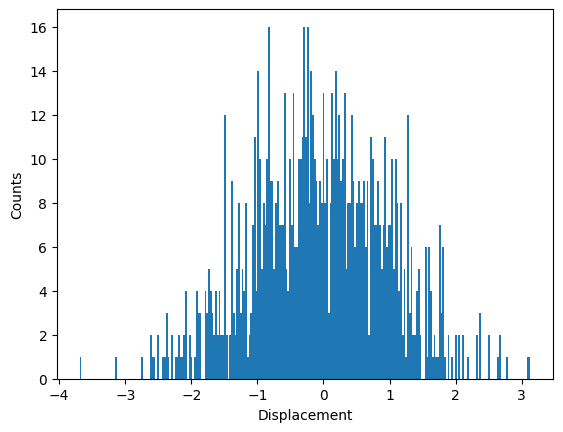

In [11]:
plt.hist(displacements, bins=256)
plt.ylabel('Counts')
plt.xlabel('Displacement')
plt.show()

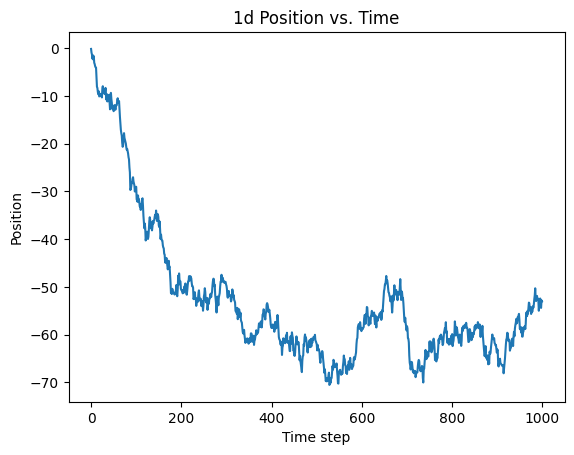

In [13]:
x = np.cumsum(displacements)
plt.plot(x)
plt.xlabel('Time step')
plt.ylabel('Position')
plt.title('1d Position vs. Time')
plt.show()

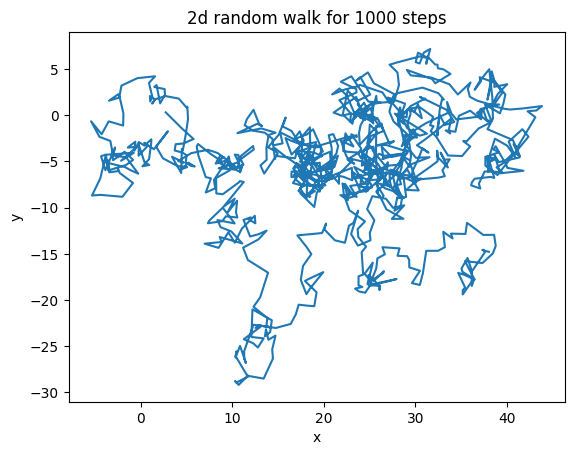

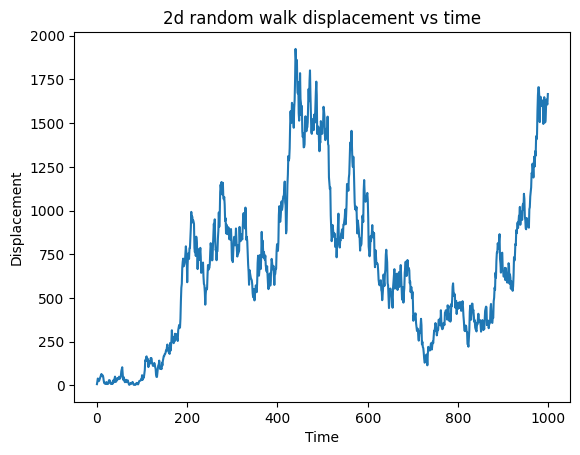

In [31]:
class Particle():
    def __init__(self, N, k=1, xoff=0, yoff=0):
        self.N = N
        self.dx = k*np.random.randn(N) + k*xoff
        self.dy = k*np.random.randn(N) + k*yoff
        self.x = np.cumsum(np.random.randn(N))
        self.y = np.cumsum(np.random.randn(N))
        self.dr_squared = self.dx**2 + self.dy**2
        self.displacement_squared = self.x **2 + self.y **2
    
    def D_calc(self, dimensions, tau):
        self.D = np.mean(self.dr_squared) / ( 2 * dimensions * tau )
        self.standard_error = np.std(self.dr_squared) / ( 2 * dimensions * tau * np.sqrt(self.N) )

N = 1000
particle = Particle(N)
plt.plot(particle.x, particle.y)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'2d random walk for {N} steps')
plt.show()

plt.plot(particle.displacement_squared)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('2d random walk displacement vs time')
plt.show()

In [19]:
#D for a 1 micron particle in water at 293 degrees Kelvin.
d    = 1.0e-6;              # diameter in meters
eta  = 1.0e-3;              # viscosity of water in SI units (Pascal-seconds) at 293 K
kB   = 1.38e-23;            # Boltzmann constant
T    = 293;                 # Temperature in degrees Kelvin

D    = kB * T / (3 * np.pi * eta * d)
print(D)

4.2901806459851315e-13


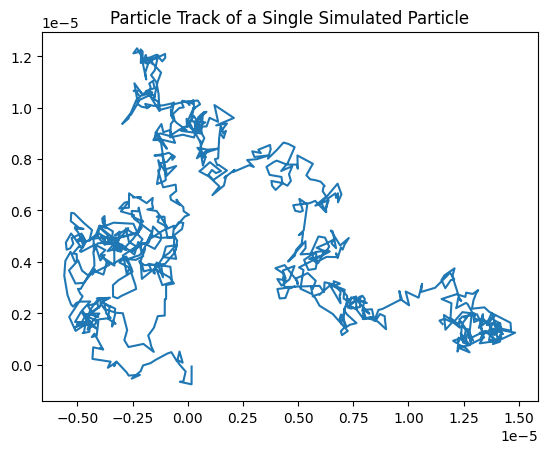

In [23]:
dimensions = 2 # two dimensional simulation
tau = 0.1 # time interval in seconds
time = tau * np.array(range(N)) # create a time vector for plotting

k = np.sqrt(D * dimensions * tau)
dx = k * np.random.randn(N)
dy = k * np.random.randn(N)

x = np.cumsum(dx)
y = np.cumsum(dy)

dSquaredDisplacement = (dx ** 2) + (dy ** 2)
squaredDisplacement = ( x ** 2) + ( y ** 2)

plt.plot(x,y)
plt.title('Particle Track of a Single Simulated Particle')
plt.show()

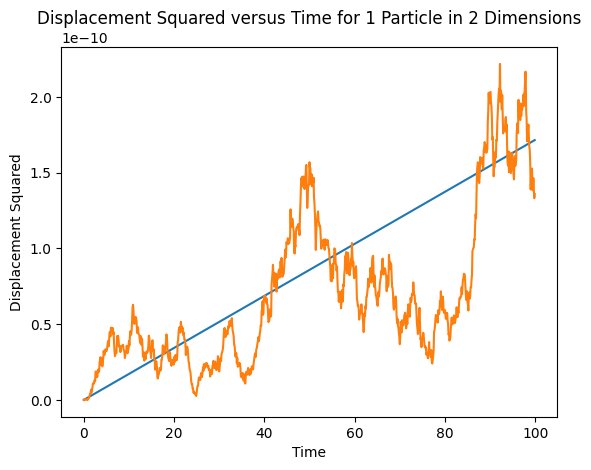

In [24]:
plt.plot(time, np.array(range(N)) * 2*k**2) # plot theoretical line
plt.plot(time, squaredDisplacement)
plt.xlabel('Time')
plt.ylabel('Displacement Squared')
plt.title('Displacement Squared versus Time for 1 Particle in 2 Dimensions')
plt.show()

In [25]:
simulatedD = np.mean( dSquaredDisplacement ) / ( 2 * dimensions * tau )
print(simulatedD)

4.43444113127702e-13


In [26]:
standardError = np.std( dSquaredDisplacement ) / ( 2 * dimensions * tau * np.sqrt(N) )
actualError = D - simulatedD
print(standardError)
print(actualError)

1.4121797671732584e-14
-1.4426048529188822e-14


4.560584868724331e-13
1.4569131955559672e-14
-2.7040422273919912e-14


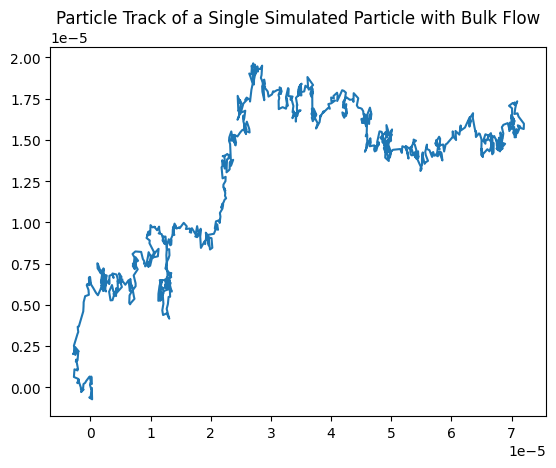

In [27]:
dx = dx + 0.2 * k
dy = dy + 0.05 * k

x = np.cumsum(dx)
y = np.cumsum(dy)

dSquaredDisplacement = (dx ** 2) + (dy ** 2)
squaredDisplacement = ( x ** 2) + ( y ** 2)

simulatedD    = np.mean( dSquaredDisplacement ) / ( 2 * dimensions * tau )
standardError = np.std(  dSquaredDisplacement ) / ( 2 * dimensions * tau * np.sqrt(N) )
actualError = D - simulatedD
print(simulatedD)
print(standardError)
print(actualError)

plt.plot(x,y)
plt.title('Particle Track of a Single Simulated Particle with Bulk Flow')
plt.show()

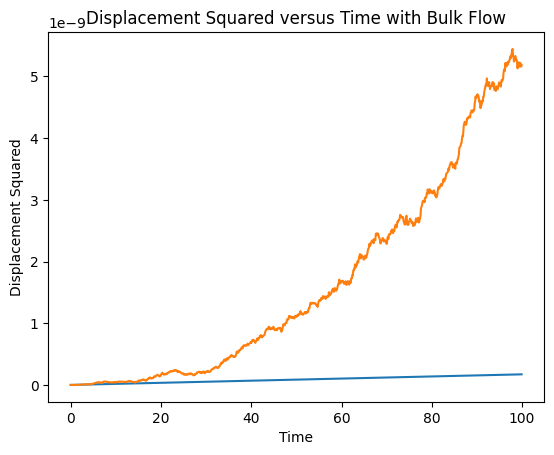

In [29]:
plt.plot(time, np.array(range(N)) * 2*k**2 ) # plot theoretical line
plt.plot(time, squaredDisplacement)
plt.xlabel('Time')
plt.ylabel('Displacement Squared')
plt.title('Displacement Squared versus Time with Bulk Flow')
plt.show()

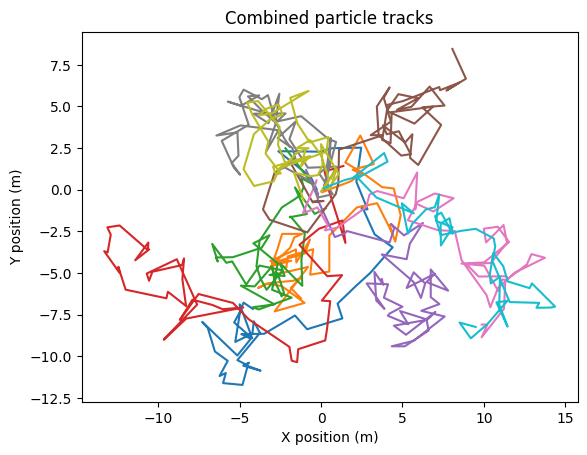

ValueError: x and y must have same first dimension, but have shapes (490,) and (50,)

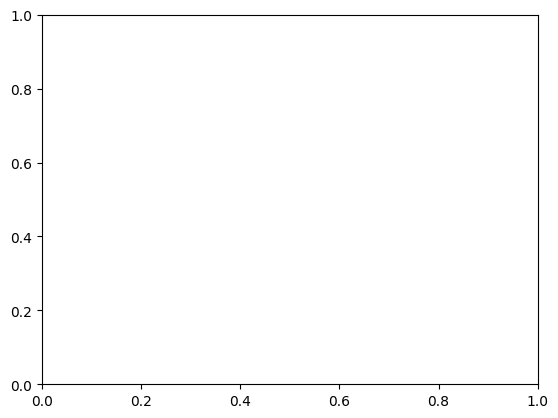

In [37]:
particleCount = 10
N = 50
tau = .1

def simulate_particles(particleCount, N, tau):
    time = np.arange(1, N, tau)
    particle = [0 for i in range(particleCount)] # create an empty cell array to hold the results
    for i in range(particleCount):
        particle[i] = Particle(N, k)
        particle[i].D_calc(dimensions=2, tau=tau)
    for i in particle:
        plt.plot(i.x, i.y)
    plt.xlabel('X position (m)')
    plt.ylabel('Y position (m)')
    plt.title('Combined particle tracks')
    return time, particle

def displacement_plot(particles, time):
    avg_displacement = np.zeros(N)
    for i in particles:
        avg_displacement += i.displacement_squared
        plt.plot(time, i.displacement_squared)
    avg_displacement /= len(particles)
    plt.plot(time, avg_displacement)
    plt.plot(time, range(N-1) * 2*k**2)
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement Squared')
    plt.title('Displacement vs time')


time, particles = simulate_particles(particleCount, N, tau)
plt.show()
displacement_plot(particles, time)
plt.show()